In [15]:
#Rutas reutilizables
from pathlib import Path

# Obtener la carpeta raíz del proyecto
ROOT = Path.cwd()

# Si el notebook se ejecuta desde notebooks, subir un nivel
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"
RAW = DATA / "raw"
EXTRACTED = DATA / "extracted"
SAMPLE = DATA / "sample50"
METADATA = DATA / "metadata"


In [1]:
#Importe de librerías
import os
import zipfile
import random

import pandas as pd
import numpy as np

import librosa

import matplotlib.pyplot as plt
import seaborn as sns 

Matplotlib is building the font cache; this may take a moment.


In [4]:
#Descompresión del archivo zip
zip_path = "../data/raw/audios.zip"

extract_path = "../data/extracted"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [5]:
#Busqueda de audios 
audio_files = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".mp3"):
            audio_files.append(os.path.join(root, file))

print("Cantidad de audios:", len(audio_files))

Cantidad de audios: 50


In [6]:
#Selección de 50 audios de prueba
random.seed(42)

sample_files = random.sample(audio_files, 50)

import shutil

os.makedirs("data/sample50", exist_ok=True)

for audio in sample_files:
    shutil.copy(audio, "data/sample50")

In [7]:
#Validadción de integridad de los audios
valid = []
invalid = []

for audio in sample_files:

    try:

        y, sr = librosa.load(audio, sr=None)

        valid.append(audio)

    except:

        invalid.append(audio)

print("Audios válidos:", len(valid))
print("Audios dañados:", len(invalid))

d:\User\Escritorio\tareas\Ciclo 8\ProyectoFinal\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Audios válidos: 50
Audios dañados: 0


In [8]:
#Estadísticas de los audios válidos
records = []

for audio in valid:

    y, sr = librosa.load(audio, sr=None)

    duration = librosa.get_duration(y=y, sr=sr)

    size = os.path.getsize(audio)/(1024*1024)

    records.append({

        "archivo":os.path.basename(audio),

        "duracion":duration,

        "sample_rate":sr,

        "tamano_MB":size

    })

df = pd.DataFrame(records)

df.head()

,archivo,duracion,sample_rate,tamano_MB
0,spontaneous-speech-es-83371.mp3,5.256,32000,0.030118
1,spontaneous-speech-es-74957.mp3,10.368,32000,0.059369
2,spontaneous-speech-es-71835.mp3,24.480,32000,0.140119
3,spontaneous-speech-es-82589.mp3,5.760,32000,0.033002
4,spontaneous-speech-es-80762.mp3,9.468,32000,0.054219


In [9]:
#Vista 
df.describe()

,duracion,sample_rate,tamano_MB
count,50.000000,50.0,50.000000
mean,6.592320,32000.0,0.037766
std,4.328481,0.0,0.024766
min,1.476000,32000.0,0.008489
25%,4.266000,32000.0,0.024453
50%,5.760000,32000.0,0.033002
75%,7.803000,32000.0,0.044692
max,24.480000,32000.0,0.140119


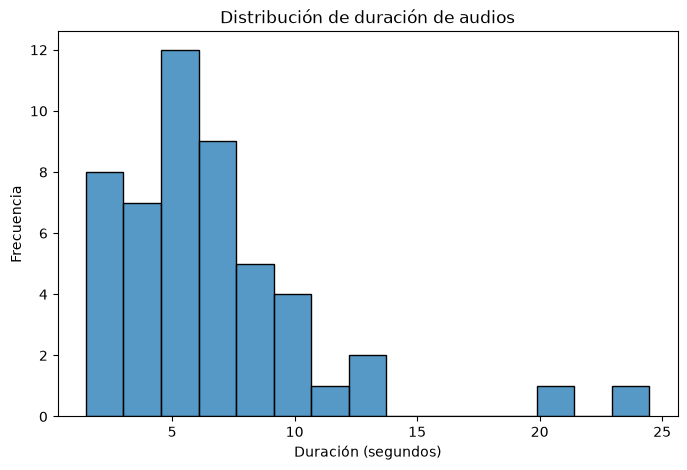

In [10]:
#Histograma de duración de los audios
plt.figure(figsize=(8,5))

sns.histplot(df["duracion"], bins=15)

plt.xlabel("Duración (segundos)")

plt.ylabel("Frecuencia")

plt.title("Distribución de duración de audios")

plt.show()

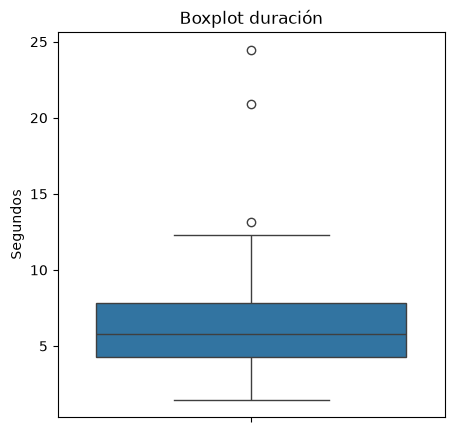

In [11]:
#Boxplot de tamaño de los audios
plt.figure(figsize=(5,5))

sns.boxplot(y=df["duracion"])

plt.ylabel("Segundos")

plt.title("Boxplot duración")

plt.show()

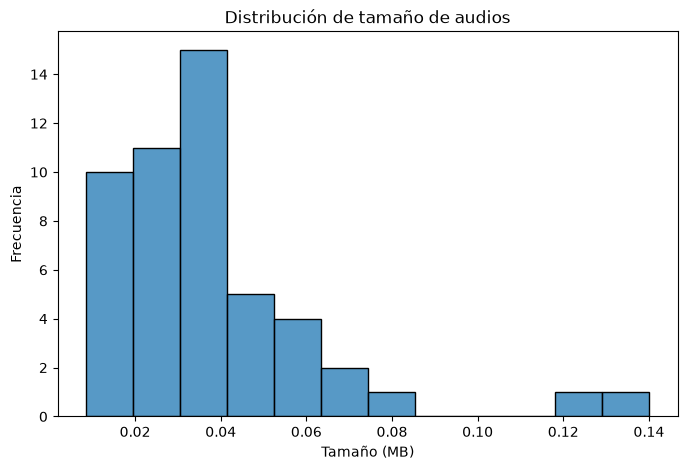

In [12]:
#Distribución de tamaño de los audios
plt.figure(figsize=(8,5))

sns.histplot(df["tamano_MB"])

plt.xlabel("Tamaño (MB)")

plt.ylabel("Frecuencia")

plt.title("Distribución de tamaño de audios")

plt.show()

In [13]:
#Verificar frecuencia de muestreo
df["sample_rate"].value_counts()

sample_rate
32000    50
Name: count, dtype: int64

In [17]:
#Guardar el DataFrame en un archivo CSV
df.to_csv(METADATA / "EDA_50_audios.csv", index=False)